In [1]:
# Step 1: Setup - Import libraries and load the Zarr dataset

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Path to your local Zarr dataset
zarr_path = "/global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/gdnat_tas_1979-2020_v2025-02-11.zarr"

# Open the Zarr dataset lazily with xarray
ds = xr.open_zarr(zarr_path, consolidated=True)

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [2]:
# Step 2: Inspect dataset structure

# Print dataset summary
print(ds)

# List all variable names
print("\nVariables in dataset:")
print(list(ds.data_vars))

# List all coordinate names
print("\nCoordinates in dataset:")
print(list(ds.coords))

# Print dataset dimensions
print("\nDataset dimensions:")
print(ds.dims)

# Optionally, inspect the first few values of key variables
for var in ds.data_vars:
    print(f"\nSample data from variable '{var}':")
    print(ds[var].isel(time=0).values)  # show first time slice


<xarray.Dataset> Size: 381GB
Dimensions:  (lat: 720, lon: 1440, model: 6, time: 15330)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * model    (model) object 48B 'ACCESS-CM2' 'CanESM5' ... 'MRI-ESM2-0'
  * time     (time) object 123kB 1979-01-01 00:00:00 ... 2020-12-31 00:00:00
Data variables:
    tas      (model, time, lat, lon) float32 381GB dask.array<chunksize=(1, 365, 100, 100), meta=np.ndarray>
Attributes:
    Created by:     Robert Fofrich <robertfofrich@ucla.edu>
    Creation date:  Compiled ZARR store created and saved 2025-02-11 01:39:52...
    Description:    GDNat: a global, daily, high-resolution natural-forcing o...
    Method:         Use Quantile Delta Mapping to apply quantile-by-quantile ...
    Repo:           https://github.com/ClimateImpactLab/gdnat
    Source files:   gs://impactlab-data/climate/attribution/outputs/hist-nat-...

Variables i

In [4]:
import xarray as xr
import numpy as np

# Total number of elements per model (used for fraction calc)
n_total_per_model = np.prod(ds.tas.shape[1:])  # time * lat * lon

# Count of NaNs per model
nan_count_by_model = ds.tas.isnull().sum(dim=["time", "lat", "lon"]).compute()

# Fraction of NaNs per model
nan_frac_by_model = nan_count_by_model / n_total_per_model

# Print results
for model, count, frac in zip(ds.model.values, nan_count_by_model.values, nan_frac_by_model.values):
    print(f"Model: {model:12s} | NaNs: {int(count):,} | Fraction: {frac:.6f}")


Model: ACCESS-CM2   | NaNs: 0 | Fraction: 0.000000
Model: CanESM5      | NaNs: 0 | Fraction: 0.000000
Model: MIROC6       | NaNs: 0 | Fraction: 0.000000
Model: NorESM2-LM   | NaNs: 0 | Fraction: 0.000000
Model: ACCESS-ESM1-5 | NaNs: 0 | Fraction: 0.000000
Model: MRI-ESM2-0   | NaNs: 0 | Fraction: 0.000000


In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np


In [7]:
tas_mean = float(ds.tas.mean().compute()) - 273.15
tas_std  = float(ds.tas.std().compute())           # in K
tas_min  = float(ds.tas.min().compute()) - 273.15
tas_max  = float(ds.tas.max().compute()) - 273.15

print(f"Mean temperature: {tas_mean:.2f} °C")
print(f"Std deviation:    {tas_std:.2f} K")
print(f"Min temperature:  {tas_min:.2f} °C")
print(f"Max temperature:  {tas_max:.2f} °C")


Mean temperature: 4.57 °C
Std deviation:    21.51 K
Min temperature:  -83.31 °C
Max temperature:  45.89 °C


In [8]:
summary_by_model = ds.tas.groupby('model').reduce(
    func=np.nanmean,
    dim=("time", "lat", "lon"),
    keep_attrs=True
).to_dataframe(name="mean_tas")

summary_by_model["std_tas"] = ds.tas.groupby('model').reduce(
    func=np.nanstd,
    dim=("time", "lat", "lon")
).values

summary_by_model["min_tas"] = ds.tas.groupby('model').reduce(
    func=np.nanmin,
    dim=("time", "lat", "lon")
).values

summary_by_model["max_tas"] = ds.tas.groupby('model').reduce(
    func=np.nanmax,
    dim=("time", "lat", "lon")
).values

# Convert from K to °C
summary_by_model["mean_tas"] -= 273.15
summary_by_model["min_tas"] -= 273.15
summary_by_model["max_tas"] -= 273.15

summary_by_model


,mean_tas,std_tas,min_tas,max_tas
model,,,,
ACCESS-CM2,4.752930,21.406374,-82.936386,45.048431
CanESM5,4.016418,21.605127,-83.290573,43.901245
MIROC6,4.677429,21.453159,-82.336136,45.889313
NorESM2-LM,4.805420,21.555494,-81.944717,44.419739
ACCESS-ESM1-5,4.502869,21.502432,-81.602356,45.565613
MRI-ESM2-0,4.654633,21.506603,-83.306061,44.551514


In [9]:
for coord in ['time', 'lat', 'lon']:
    n_nans = ds[coord].to_index().isnull().sum()
    print(f"NaNs in {coord}: {n_nans}")


NaNs in time: 0
NaNs in lat: 0
NaNs in lon: 0


In [10]:
print(ds.time.to_index().isnull().sum())  # Should be 0


0


In [11]:
# Comprehensive NA Check

import numpy as np

print("Checking missing values for all data variables:\n")

for var in ds.data_vars:
    n_missing = int(ds[var].isnull().sum().compute())
    total = np.prod(ds[var].shape)
    frac = n_missing / total if total > 0 else 0
    print(f"Variable '{var}': {n_missing:,} missing values out of {total:,} ({frac:.6%})")

print("\nChecking missing values in coordinates:\n")

coords_to_check = ['time', 'lat', 'lon', 'model']

for coord in coords_to_check:
    if coord in ds.coords:
        # Coordinates are usually 1D arrays, convert to pandas index for null check
        n_missing = ds[coord].to_index().isnull().sum()
        total = ds[coord].size
        frac = n_missing / total if total > 0 else 0
        print(f"Coordinate '{coord}': {n_missing} missing values out of {total} ({frac:.6%})")
    else:
        print(f"Coordinate '{coord}' not found in dataset.")

print("\nComprehensive NA check complete.")


Checking missing values for all data variables:

Variable 'tas': 0 missing values out of 95,364,864,000 (0.000000%)

Checking missing values in coordinates:

Coordinate 'time': 0 missing values out of 15330 (0.000000%)
Coordinate 'lat': 0 missing values out of 720 (0.000000%)
Coordinate 'lon': 0 missing values out of 1440 (0.000000%)
Coordinate 'model': 0 missing values out of 6 (0.000000%)

Comprehensive NA check complete.


/tmp/ipykernel_777196/768061385.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


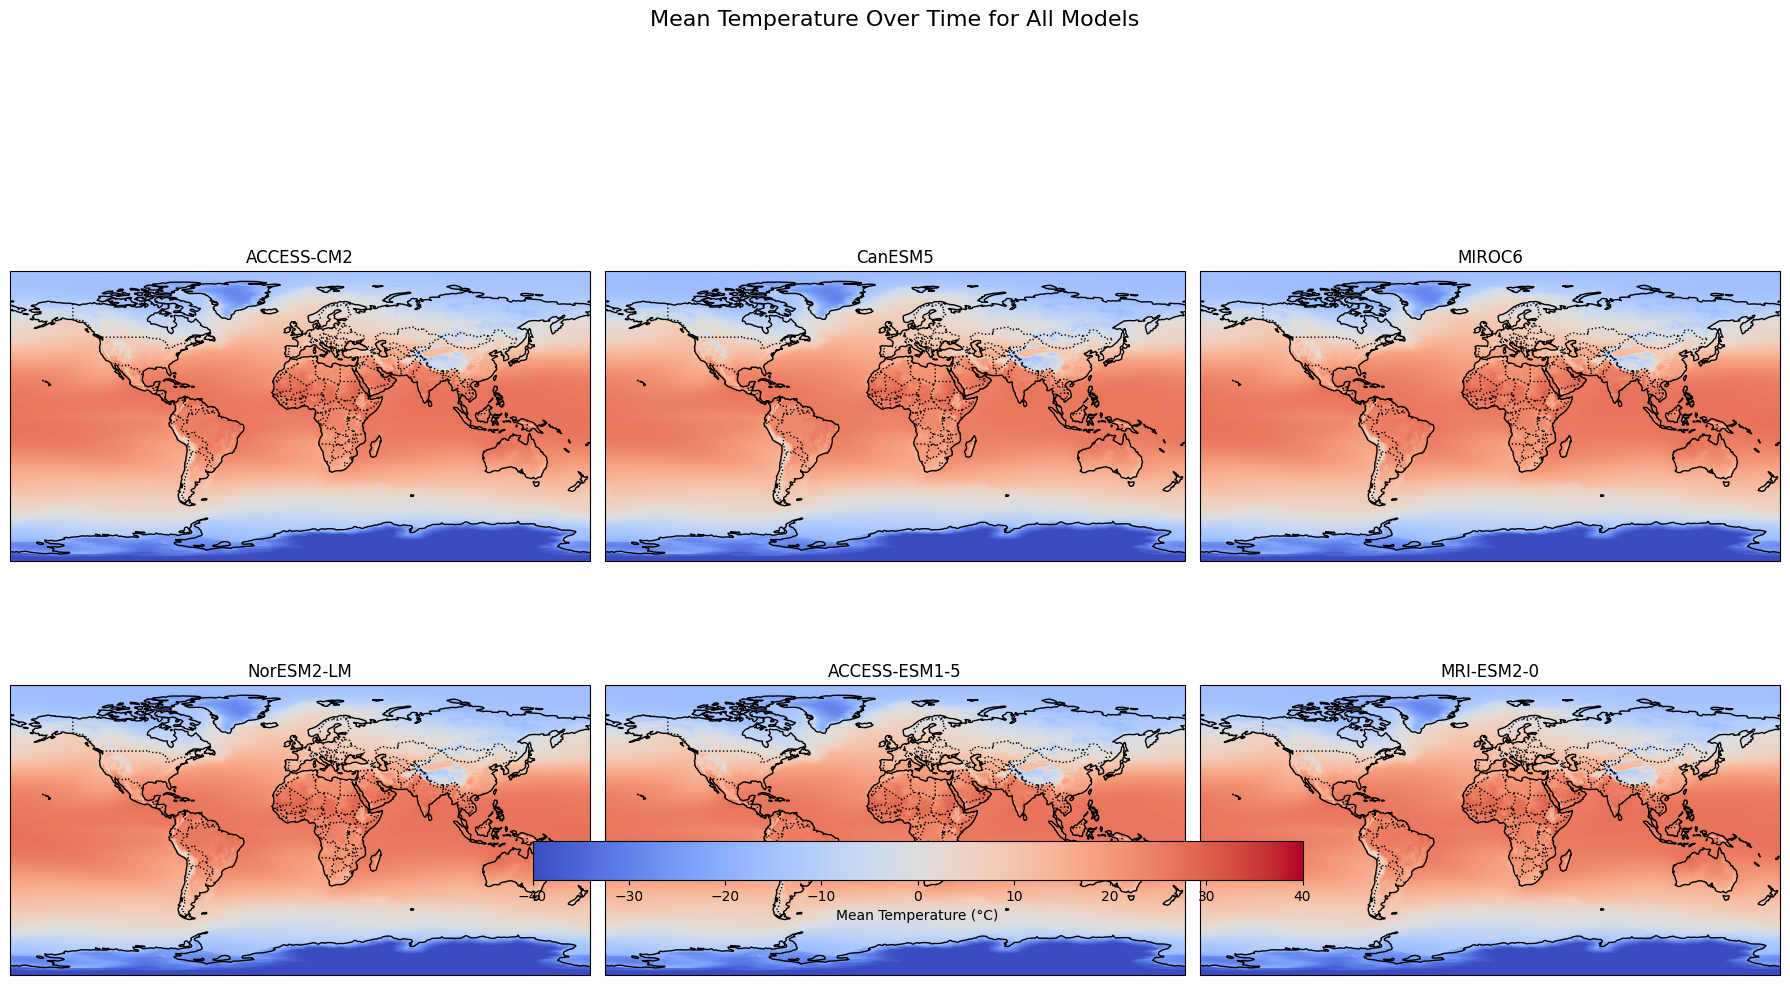

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

models = ds.model.values
n_models = len(models)

# Shift longitudes from [0,360) to [-180,180)
ds_shifted = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')

fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

vmin, vmax = -40, 40  # consistent color scale for all plots

for i, model_name in enumerate(models):
    # Compute mean over time for this model
    tas_mean = ds.tas.sel(model=model_name).mean(dim='time').compute() - 273.15

    ax = axes[i]
    im = tas_mean.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_title(model_name)

# Add a single colorbar for all subplots
cbar = fig.colorbar(im, ax=axes.tolist(), orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Mean Temperature (°C)')

plt.suptitle('Mean Temperature Over Time for All Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you already opened the file
# ds = xr.open_mfdataset(...)

annual_df = pd.DataFrame()

for model_name in ds.model.values:
    print(f"Processing model: {model_name}")
    
    # Subset for this model
    ds_model = ds.sel(model=model_name)
    
    # Area weighting: weight by cos(lat)
    weights = np.cos(np.deg2rad(ds_model.lat))
    weights.name = "weights"
    
    # Compute area-weighted global mean temperature for each time step
    weighted_mean_time = ds_model.tas.weighted(weights).mean(dim=["lat", "lon"])
    
    # Convert to Pandas Series
    tas_series = weighted_mean_time.to_series()
    
    # Drop missing values (some CFTime conversions may leave NAs)
    tas_series = tas_series.dropna()
    
    # Convert CFTimeIndex to datetime64 (only if possible)
    try:
        tas_series.index = xr.cftime_range(
            start=str(tas_series.index[0]),
            periods=len(tas_series),
            freq="D"
        ).to_datetimeindex()
    except Exception:
        tas_series.index = pd.to_datetime(tas_series.index.to_timestamp())  # fallback
    
    # Resample to yearly mean
    yearly_mean = tas_series.resample('YS').mean()
    yearly_mean.name = model_name
    
    # Add to DataFrame
    annual_df[model_name] = yearly_mean

Processing model: ACCESS-CM2


/tmp/ipykernel_777196/4283376962.py:32: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  tas_series.index = xr.cftime_range(
/tmp/ipykernel_777196/4283376962.py:36: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ).to_datetimeindex()


Processing model: CanESM5


/tmp/ipykernel_777196/4283376962.py:32: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  tas_series.index = xr.cftime_range(
/tmp/ipykernel_777196/4283376962.py:36: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ).to_datetimeindex()


Processing model: MIROC6


...

/tmp/ipykernel_777196/4283376962.py:32: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  tas_series.index = xr.cftime_range(
/tmp/ipykernel_777196/4283376962.py:36: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ).to_datetimeindex()


Processing model: ACCESS-ESM1-5


/tmp/ipykernel_777196/4283376962.py:32: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  tas_series.index = xr.cftime_range(
/tmp/ipykernel_777196/4283376962.py:36: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ).to_datetimeindex()


Processing model: MRI-ESM2-0


/tmp/ipykernel_777196/4283376962.py:32: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  tas_series.index = xr.cftime_range(
/tmp/ipykernel_777196/4283376962.py:36: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ).to_datetimeindex()


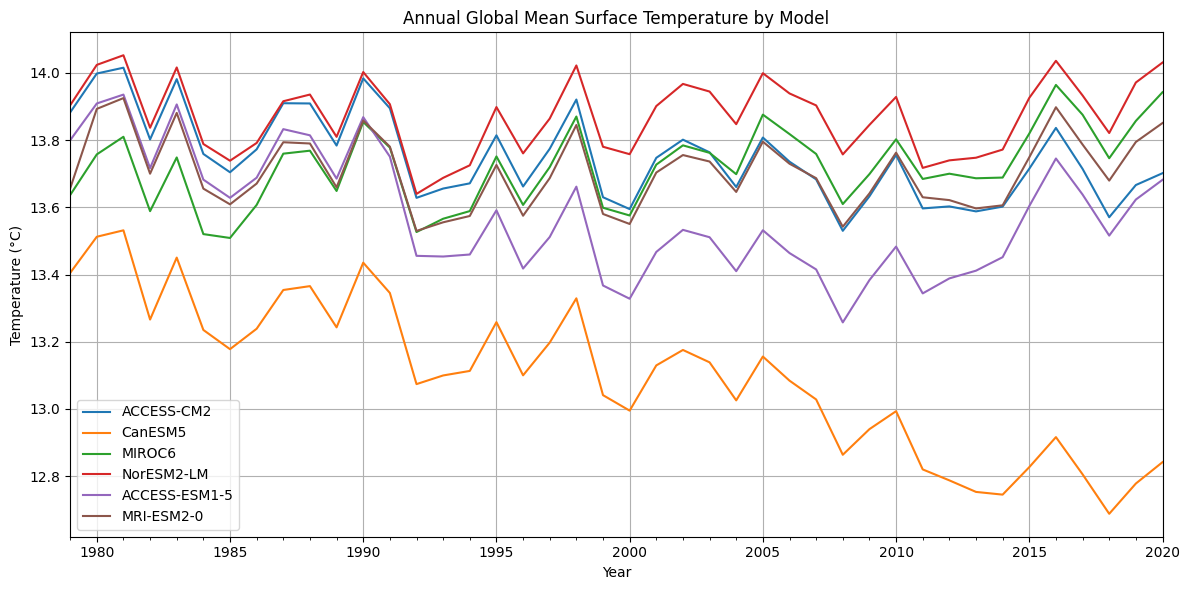

In [21]:

# Convert all temperature values from Kelvin to Celsius
annual_df_celsius = annual_df - 273.15

# Plot all model annual time series
annual_df_celsius.plot(figsize=(12, 6), title="Annual Global Mean Surface Temperature by Model")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
tas_c = ds.tas - 273.15
weights = np.cos(np.deg2rad(ds.lat))
weights = weights / weights.sum()
single_mean = tas_c.isel(time=0).weighted(weights).mean(("lat", "lon"), skipna=True)
print(single_mean.values)


[11.91966591 11.50731566 11.62690981 11.90840978 11.85597967 11.63295067]
